In [2]:
import requests

file_url = "https://video-downloads.googleusercontent.com/ADGPM2kh4M2OkofHfZNP-0dn2ZtLFXLRUYLVabVtuJFCOxSP3nrH3CvwVU0eGa6kOybCD68Rn9tf4ffWa40aHe1l8wt2hxOFm4hYE8PIKbTDeMkeuA6pW5qxsgHQ1IHI87quHv9tPjtMHNN_bOdmlTQE6IShpnpv1WnhjsxOve4MGiaac6NlOFbGBZfkcQ11gFf5ZgG-Ah6H05GxLsgGH1sL9I01a8b8PLTSOlF-VUk-WKxOGTUcs_msQV4KQTMt4W98HND5681BsusMThYTyYj3V-d4OcKXcZ2TcQYfU_BIhJseVDBd42-e4h13mfJHsxjPTvdjPVTBYT6-d3U5aCxVIpr7NoZulEg8O1QHJJnpF5CX2jJopsSi4smMVF2nNGOEcBkJDxfAralWCVMaCfJKEW7EaZ1tzU6Gt6nrfh7l5CAS9LhVitaIN0_ChZRu5X6mfxaaEfEX1zqI0z-35_aryxZZabL6LARt2I9417GKeg18eotD-or7ijT7UFAQ_fD3xLrGMRjJDgFpkiYihKg9NDTAaZewibUNBXKNPEfzpzr4Xziabo5UMVFpdLHKsdlgBf-nS4zNaSYpNk7VBffayLbQg_qKYNKf5VDDNSChqjKuXvHBN2Ss5q_jGA4k7bI0pdboAJ0LBdVlxWu6ZZDTzT4w4iqDtlapheKGI7vARrE3CZFILtjIhfo7_2FwZLwyo7-_06OGx3ZfaMnFqpmPZ1xqNJ127hBCyztzrTmqIlVamX6Lw6rHJZchu8GIa-UqoBZdbrlqixfFnsNX8j5W5Aj6QXsiwi25-9HBeToSiC6Wehn8zsTEaBneL9calzteiAyVKm8cqSafkzQiQCa97OBKtb4HgVExv1tdpGiGGtw4EbIFCpGspzt9cwXwtT8ABnhJnuqCijbzO2KKx7yUri3dPPD_NCVPhBS0mWUwW_Lk7D9OziLqkWP1hqff0cetOZ1Or3ZUI61crKdqiBi60xk9dWFs6qipgNJWDAAHUqvprljzDWluf1537o3N_AXugdIrE2LhR1xYG1ommbfs9jlAkOhGTifVYOHqUDRO6BwBIbO3UoTXlYqMkzI27cPkz-zS6matyJjXayjeTJ-h0Xxqu0qqQaPchH5XnQP3ExwYZUB_dJMDRq8WjPI7IB8xiRNyCoX2Rkwtp2sT7EOOLBdDXlgzz4kR-pmqSu9ymZe7PyVYFddsgIb-IqK0rs3tkr5NlUSV_QfwW77mb8BQ4IhkM6XH7NtPhBUNks0GOMECbksRoybV1_cLFrMWd3el3aykfRww"

requests.get(file_url)

file_name = "zipped.zip"

response = requests.get(file_url, stream=True)

# Ensure the request was successful
if response.status_code == 200:
    with open(file_name, 'wb') as f:
        for chunk in response.iter_content(chunk_size=128):
            f.write(chunk)
    print(f"Download complete: {file_name}")
else:
    print("Failed to download the file.")


Failed to download the file.


In [ ]:
%unzip zipped.zip -d images

unzip:  cannot find either zipped.zip or zipped.zip.zip.


In [6]:
%pip install ultralytics

Defaulting to user installation because normal site-packages is not writeable
  Using cached ultralytics-8.3.100-py3-none-any.whl.metadata (37 kB)
  Using cached matplotlib-3.10.1-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached torchvision-0.21.0-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
  Using cached pandas-2.2.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached ultralytics_thop-2.0.14-py3-none-any.whl.metadata (9.4 kB)
Using cached ultralytics-8.3.100-py3-none-any.whl (977 kB)
Using cached matplotlib-3.10.1-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached pandas-2.2.3-cp312-cp312-win_amd64.whl (11.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached torchvision-0.21.0-cp312-cp312-win_amd64.whl (1.6 MB)
Using cached ultralytics_thop-2.0.14-py3-none-any.whl (26 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict

model = YOLO("yolov8m.pt")  # load a pretrained model

def object_detection(image):
    detections = defaultdict(int)

    # Perform object detection
    results = model(image)

    # Extract the bounding boxes and class labels
    boxes = results[0].boxes
    class_names = results[0].names

    # Iterate over the detected objects
    for box in boxes:
        # Get the bounding box coordinates
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

        # Get the class label and confidence score
        class_id = int(box.cls[0].tolist())
        class_name = class_names[class_id]
        confidence = round(float(box.conf[0]), 2)

        # Increment the count for the detected object
        detections[class_name] += 1

        # Draw the bounding box on the image
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Calculate the text size for the label
        text_size = cv2.getTextSize(class_name, cv2.FONT_HERSHEY_SIMPLEX, 0.9, 2)[0]

        # Place the label inside the bounding box
        label_x = x1 + 5
        label_y = y1 + text_size[1] + 5
        label = f"{class_name}: {confidence}"
        cv2.putText(image, label, (label_x, label_y), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    return image, detections

# Load an image
image = cv2.imread("/content/images/PXL_20240121_011141428.jpg")

# Perform object detection
image_with_boxes, object_counts = object_detection(image)

# Display the image with bounding boxes and labels
plt.figure(figsize=(20, 15))  # You can adjust the size as needed

# Display the image with bounding boxes and labels, making sure the color Wmapping is correct
plt.imshow(cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB))

# Hide the axes
plt.axis('off')

# Show the image
plt.show()

# Print the object counts
print("Object Counts:")
for object_name, count in object_counts.items():
    print(f"{object_name}: {count}")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\acer\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 49.7M/49.7M [00:05<00:00, 9.92MB/s]


FileNotFoundError: [Errno 2] No such file or directory: '/content/images/PXL_20240121_011141428.jpg'

In [10]:
from ultralytics import YOLO
import cv2

model = YOLO("yolov8m.pt")
cap = cv2.VideoCapture(0)  # 0 = default webcam

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)
    boxes = results[0].boxes
    names = results[0].names

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        class_id = int(box.cls[0].tolist())
        class_name = names[class_id]
        confidence = float(box.conf[0])

        label = f"{class_name} ({confidence:.2f})"
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    cv2.imshow("Live YOLOv8 Detection", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()



0: 480x640 1 person, 1 bed, 282.3ms
Speed: 3.6ms preprocess, 282.3ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 dog, 1 bed, 247.8ms
Speed: 2.3ms preprocess, 247.8ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 dog, 1 bed, 239.4ms
Speed: 1.4ms preprocess, 239.4ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 dog, 256.0ms
Speed: 2.0ms preprocess, 256.0ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 dog, 259.5ms
Speed: 1.6ms preprocess, 259.5ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 dog, 1 bed, 244.6ms
Speed: 1.1ms preprocess, 244.6ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 dog, 231.2ms
Speed: 1.5ms preprocess, 231.2ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 dog, 1 bed

KeyboardInterrupt: 

In [11]:
%pip install pyttsx3


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from ultralytics import YOLO
import cv2
import pyttsx3
import time

# Use a faster model (nano)
model = YOLO("yolov8n.pt")

# Setup TTS engine
tts = pyttsx3.init()
tts.setProperty("rate", 150)

# Variables to manage TTS cooldown
last_spoken_objects = set()
last_spoken_time = 0
speak_delay = 3  # seconds

# Start webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)
    boxes = results[0].boxes
    names = results[0].names

    current_objects = set()

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        class_id = int(box.cls[0].tolist())
        class_name = names[class_id]
        confidence = float(box.conf[0])

        if confidence < 0.5:
            continue  # ignore low-confidence detections

        current_objects.add(class_name)

        # Draw box and label
        label = f"{class_name} ({confidence:.2f})"
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    # Speak only if:
    # - Objects are new
    # - It's been at least `speak_delay` seconds since last spoken
    current_time = time.time()
    if current_objects and (current_objects != last_spoken_objects) and (current_time - last_spoken_time > speak_delay):
        spoken_text = "I see " + ", ".join(current_objects)
        print(spoken_text)
        tts.say(spoken_text)
        tts.runAndWait()
        last_spoken_objects = current_objects
        last_spoken_time = current_time

    cv2.imshow("YOLOv8 Real-Time Detection + TTS", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


100%|██████████| 6.25M/6.25M [00:00<00:00, 8.62MB/s]



0: 480x640 1 person, 72.1ms
Speed: 2.7ms preprocess, 72.1ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)
I see person

0: 480x640 1 person, 42.4ms
Speed: 1.5ms preprocess, 42.4ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 43.5ms
Speed: 1.0ms preprocess, 43.5ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 43.3ms
Speed: 1.0ms preprocess, 43.3ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 45.1ms
Speed: 1.1ms preprocess, 45.1ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 47.4ms
Speed: 1.0ms preprocess, 47.4ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 46.0ms
Speed: 1.2ms preprocess, 46.0ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 47.0ms
Speed: 0.9ms preprocess, 47.0ms inference, 0.9ms postprocess per image at sh

KeyboardInterrupt: 

In [ ]:
object_detection('/content/images')

WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.10/dist-packages/ultralytics/assets'.


defaultdict(int,
            {'person': 177,
             'book': 3,
             'stop sign': 1,
             'airplane': 2,
             'bench': 6,
             'orange': 2,
             'vase': 1,
             'potted plant': 2,
             'bus': 6,
             'cup': 1,
             'chair': 7,
             'mouse': 1,
             'horse': 1,
             'baseball bat': 1,
             'sandwich': 2,
             'sports ball': 2,
             'bird': 3,
             'car': 3,
             'cell phone': 1,
             'bed': 1,
             'teddy bear': 1,
             'bowl': 4,
             'bottle': 1})

In [8]:
%pip install mtcnn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   --------------------------- ------------ 1.3/1.9 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 1.9/1.9 MB 10.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
%pip install onnxruntime

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.8 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.8 MB 10.1 MB/s eta 0:00:02
   ------------------ --------------------- 5.5/11.8 MB 18.7 MB/s eta 0:00:01
   ------------------------------------- -- 11.0/11.8 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------- 11.8/11.8 MB 19.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from mtcnn import MTCNN
import onnxruntime as ort

In [ ]:
def detect_faces_mtcnn(image_path):

  # Load the pre-trained MTCNN model
  detector = MTCNN()

  # Load an image
  image = cv2.imread(image_path)
  real = image.copy()
  image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

  # Detect faces in the image

  faces = detector.detect_faces(image_rgb)

  # Draw bounding boxes around the faces
  for face in faces:
      x, y, w, h = face['box']
      cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)

  # Display the result

  fig, axs = plt.subplots(1,2)
  axs[0].set_title("Real Image")
  axs[1].set_title("Modified Image")
  axs[0].imshow(cv2.cvtColor(real, cv2.COLOR_BGR2RGB))
  axs[1].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  plt.figure(figsize=(20, 15))


2/2 [==============================] - 0s 7ms/step


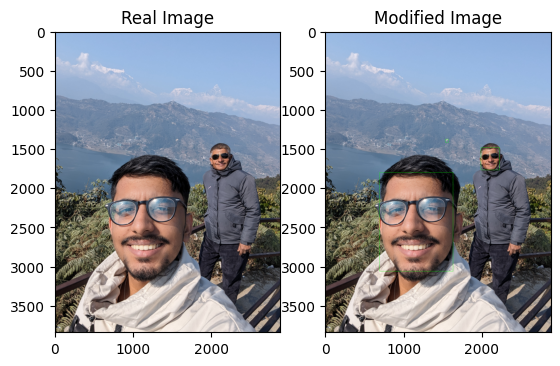

<Figure size 2000x1500 with 0 Axes>

In [ ]:
detect_faces_mtcnn("/content/images/PXL_20240125_041916495.jpg")